# Physics-Informed Neural Network for 1D Steady Heat Conduction

This notebook is an introductory implementation of a PINN using PyTorch automatic differentiation.

The governing equation is:
\[
    \frac{d^2T}{dx^2}=0,
    \qquad 0\leq x\leq1
\]

with boundary conditions

\[
T(0)=30,
\qquad
T(1)=80.
\]

The analytical solution is

\[
T(x)=30+50x.
\]

The PINN is trained by minimizing the PDE residual together with the boundary-condition errors. The final prediction is compared with the analytical solution.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

# Collocation points in the domain 0 <= x <= 1
x_colloc = torch.linspace(0,1,50).view(-1,1)

# Required because derivatives with respect to x will be calculated
x_colloc.requires_grad_(True)

# Neural network: x -> T(x)
model = nn.Sequential(
    nn.Linear(1,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.Tanh(),
    nn.Linear(32,1)
)

# Boundary locations
x_left = torch.tensor([[0.0]])
x_right = torch.tensor([[1.0]])

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

# Scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.5
)

In [2]:
n_epochs = 3000

for epoch in range(n_epochs):
    # Forward pass: predict temperature
    T = model(x_colloc)

    # Automatic differentiation
    dT_dx = torch.autograd.grad(T, x_colloc, grad_outputs=torch.ones_like(T), create_graph=True)[0]
    d2T_dx2 = torch.autograd.grad(dT_dx, x_colloc, grad_outputs=torch.ones_like(dT_dx), create_graph=True)[0]

    # PDE loss (Governing equation: d²T/dx² = 0)
    loss_pde = torch.mean(d2T_dx2**2)

    # Boundary-condition loss: T(0) = 30; T(1) = 80
    T_left = model(x_left)
    T_right = model(x_right)
    loss_bc = (
        torch.mean((T_left - 30.0)**2)
        + torch.mean((T_right - 80.0)**2)
    )

    # Total PINN loss
    loss = loss_pde + loss_bc

    # Update NN parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Display training progress
    if epoch % 300 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"PDE loss = {loss_pde.item():.6f} | "
            f"BC loss = {loss_bc.item():.6f} | "
            f"Total loss = {loss.item():.6f}"
        )


Epoch    0 | PDE loss = 0.094890 | BC loss = 7347.397461 | Total loss = 7347.492188
Epoch  300 | PDE loss = 29.589575 | BC loss = 543.018127 | Total loss = 572.607727
Epoch  600 | PDE loss = 1.387172 | BC loss = 4.604164 | Total loss = 5.991336
Epoch  900 | PDE loss = 0.212536 | BC loss = 0.048987 | Total loss = 0.261523
Epoch 1200 | PDE loss = 0.101567 | BC loss = 0.005725 | Total loss = 0.107292
Epoch 1500 | PDE loss = 0.067723 | BC loss = 0.002115 | Total loss = 0.069839
Epoch 1800 | PDE loss = 0.047424 | BC loss = 0.000964 | Total loss = 0.048388
Epoch 2100 | PDE loss = 0.036386 | BC loss = 0.000558 | Total loss = 0.036944
Epoch 2400 | PDE loss = 0.031181 | BC loss = 0.000407 | Total loss = 0.031588
Epoch 2700 | PDE loss = 0.026715 | BC loss = 0.000297 | Total loss = 0.027012


## Evaluation

The trained PINN is evaluated at several points and compared with the analytical solution

\[
T(x)=30+50x.
\]

In [3]:
x_check = torch.linspace(0, 1, 5).view(-1, 1)

model.eval()
with torch.no_grad():
    T_pred = model(x_check)

print("PINN vs analytical solution\n")

for i in range(len(x_check)):
    x_val       = x_check[i].item()
    pinn_val    = T_pred[i].item()
    exact_val   = 30 + 50*x_val

    print(
        f"x = {x_val:.2f} | "
        f"PINN = {pinn_val:.4f} | "
        f"Exact = {exact_val:.4f}"
    )



PINN vs analytical solution

x = 0.00 | PINN = 29.9985 | Exact = 30.0000
x = 0.25 | PINN = 42.4952 | Exact = 42.5000
x = 0.50 | PINN = 54.9919 | Exact = 55.0000
x = 0.75 | PINN = 67.4885 | Exact = 67.5000
x = 1.00 | PINN = 79.9853 | Exact = 80.0000


## Solution Comparison
The trained PINN prediction is compared with the analytical temperature distribution across the full domain.

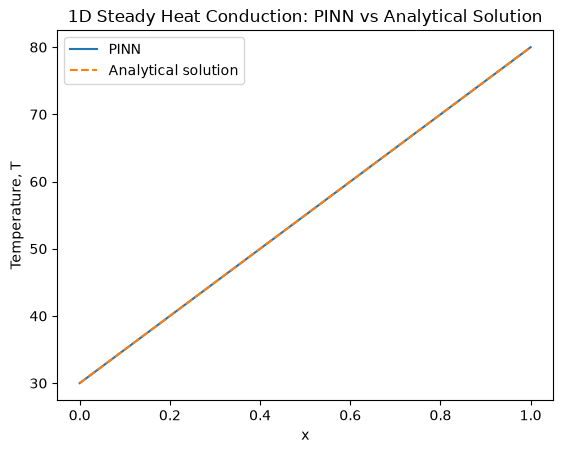

In [4]:
x_plot = torch.linspace(0, 1, 100).view(-1,1)

model.eval()

with torch.no_grad():
    T_pinn = model(x_plot)

T_exact = 30 + 50*x_plot

plt.plot(
    x_plot.numpy(),
    T_pinn.numpy(),
    label="PINN"
)

plt.plot(
    x_plot.numpy(),
    T_exact.numpy(),
    "--",
    label="Analytical solution"
)

plt.xlabel("x")
plt.ylabel("Temperature, T")
plt.title("1D Steady Heat Conduction: PINN vs Analytical Solution")
plt.legend()
plt.show()